In [2]:
##import libraries##
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import pandas as pd
import imagecodecs
import healpy as hp

(720, 1440)


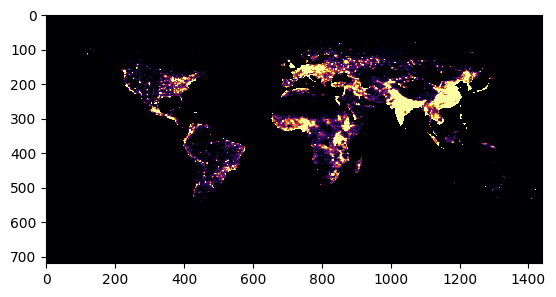

In [3]:
##read the tif file##

image=tiff.imread('/media/sf_Shared_Ubuntu/MAPS/gpw_v4_population_density_adjusted_to_2015_unwpp_country_totals_rev11_2020_15_min.tif')
image_array=np.array(image)
#image_array[image_array==np.min(image_array)]=np.min(image_array)

plt.imshow(image_array, cmap='inferno',vmin=0,vmax=100)
print(np.shape(image_array))


In [7]:
##HEALPix scheme for image array##
#spherical co-ordinates#
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)
#set angular resolution#
nside = 256
print("Pixel area: %.2f square degrees" % hp.nside2pixarea(nside, degrees=True))
print(np.size(theta),np.size(phi))
print(np.size(theta))
print(np.size(phi))
print(np.max(image_array))
print(np.shape(np.ndarray.flatten(image_array)))

Pixel area: 0.05 square degrees
720 1440
720
1440
27643.41
(1036800,)


In [8]:
##Allocate HEALPix Map to image array##
pix=[]
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=np.int64)
for i in range(len(theta)):
    for j in range(len(phi)):
        pix.append(hp.ang2pix(nside,theta[i],phi[j]))
       
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
healpix_map[pix]=np.ndarray.flatten(image_array)
print(np.shape(healpix_map))

(786432,)


<IPython.core.display.Javascript object>


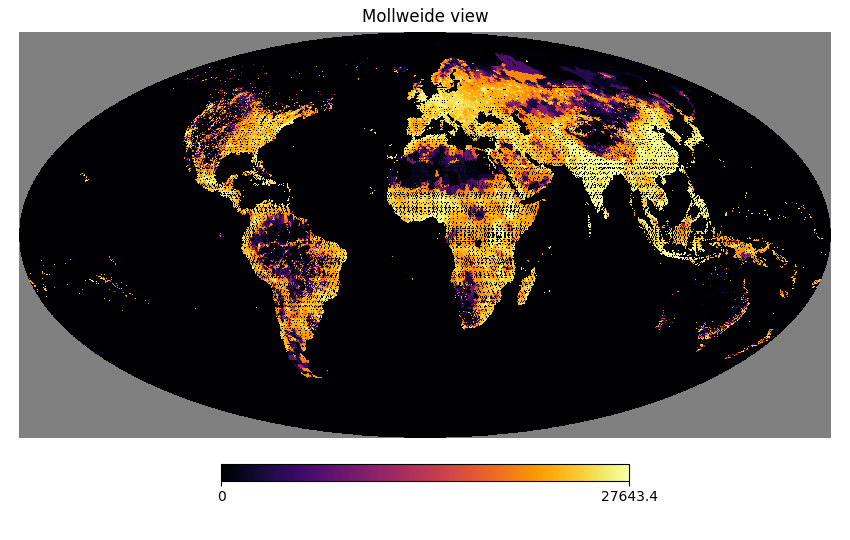

In [9]:
%matplotlib notebook

hp.mollview(healpix_map,cmap="inferno",xsize=3000, flip="geo",norm="hist",min=0)
plt.show()

In [6]:
cord=hp.pix2ang(nside,686,lonlat=True)

print(cord)
pixel=hp.ang2pix(nside,np.radians(102),np.radians(102),lonlat=True)
value=healpix_map[pixel]
print(pixel)

(11.842105263157896, 86.52738119225936)
380421


In [7]:
cord1=hp.pix2ang(nside,686,lonlat=True)
print(cord1)


(11.842105263157896, 86.52738119225936)


In [8]:
np.size(image_array)

1036800

<IPython.core.display.Javascript object>


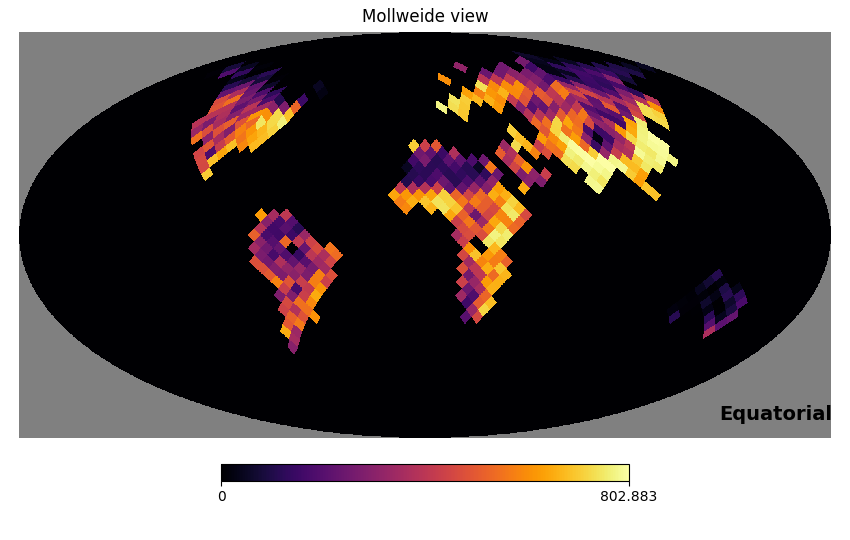

879


In [9]:
healpix_map_ns16=hp.pixelfunc.ud_grade(healpix_map,16)
%matplotlib notebook
hp.mollview(healpix_map_ns16,cmap="inferno", xsize=2000, coord="C",norm="hist",flip="geo",min=0)
plt.show()
print(np.argmax(healpix_map_ns16))

In [10]:
print(np.max(healpix_map_ns16))

802.8829618692398
